In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt 

In [2]:
def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]

        return title, data[:, 0], data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

        return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]



def save_two_column_text(data, filename):                                                         
      """                                                                                           
      Save 2-column data to a text file with whitespace separation.                                 
                                                                                                    
      Parameters                                                                                    
      ----------                                                                                    
      data : array-like, shape (N, 2)                                                               
          Two-column data to save. Can be a list of tuples, 2D numpy array, etc.                    
      filename : str                                                                                
          Path to the output text file.                                                             
                                                                                                    
      Examples                                                                                      
      --------                                                                                      
      >>> data = [[1.0, 2.5], [3.0, 4.2], [5.0, 6.8]]                                               
      >>> save_two_column_text(data, 'output.txt')                                                  
      """                                                                                           
      data = np.asarray(data)                                                                       
      if data.ndim != 2 or data.shape[1] != 2:                                                      
          raise ValueError(f"Data must be 2-column array, got shape {data.shape}")                  
                                                                                                    
      np.savetxt(filename, data, fmt='%.18e', delimiter=' ')                                        
                               

def read_two_column_text(filename):                                                               
      """                                                                                           
      Read 2-column data from a text file with whitespace separation.                               
                                                                                                    
      Parameters                                                                                    
      ----------                                                                                    
      filename : str                                                                                
          Path to the input text file.                                                              
                                                                                                    
      Returns                                                                                       
      -------                                                                                       
      data : numpy.ndarray, shape (N, 2)                                                            
          Two-column data array.                                                                    
                                                                                                    
      Examples                                                                                      
      --------                                                                                      
      >>> data = read_two_column_text('output.txt')                                                 
      >>> col1, col2 = data[:, 0], data[:, 1]                                                       
      """                                                                                           
      data = np.loadtxt(filename)                                                                   
      if data.ndim == 1:  # Single row case                                                         
          data = data.reshape(1, -1)                                                                
      if data.shape[1] != 2:                                                                        
          raise ValueError(f"File must contain exactly 2 columns, got {data.shape[1]}")             
                                                                                                    
      return data  


In [3]:
import numpy as np
title, data_1,data_2 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/DataposBias.dat')
title, data_3, data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/DatanegBias.dat')

eta_list = [0.15]
temp_list = [0.45]
phonon_scattering_list = [0.00]
labels = []
dc_biases = [0.52,-0.52,0.0]
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            for dc_bias in dc_biases:
                filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + ' DC_bias:' + str(np.round(dc_bias,2)) + '.pkl'
                data_theory_dictionaries += [load_file(filename)]
                labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(110, 2)
(110, 2)
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(25, 150)
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(25, 150)
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(25, 150)
0.83793104


/tmp/ipykernel_16721/334015948.py:20: RuntimeWarning: invalid value encountered in divide
  crt_transmitivity = (np.max(np.array(crt_dict['current_vs_time'])[:,crt_dict['times'][0] > -7], axis = 1) - dc_offset_true)/ (x_data )
/tmp/ipykernel_16721/334015948.py:35: RuntimeWarning: divide by zero encountered in divide
  crt_transmitivity = (np.max(np.array(crt_dict['current_vs_time'])[:,crt_dict['times'][0] > -7], axis = 1) - dc_offset_true)/ (x_data )
/tmp/ipykernel_16721/334015948.py:39: RuntimeWarning: invalid value encountered in multiply
  axs.scatter(x_data * crt_transmitivity,1- crt_transmitivity, marker = 'd', color = 'dodgerblue', s = 120, label = r'Theory-neg')
/tmp/ipykernel_16721/334015948.py:40: RuntimeWarning: invalid value encountered in multiply
  axs.plot(x_data* crt_transmitivity,1- crt_transmitivity, color = 'dodgerblue', linewidth = 2.5)
/tmp/ipykernel_16721/334015948.py:41: RuntimeWarning: invalid value encountered in multiply
  save_two_column_text(data = np.array([

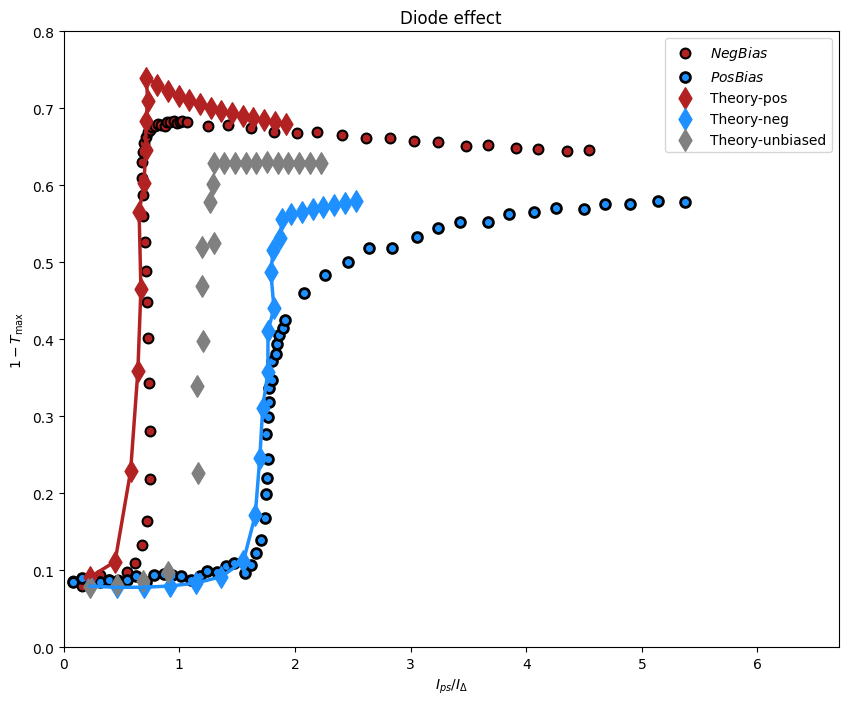

In [8]:

I_c = 37.3
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$1 - T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}/I_{\Delta}$')
axs.set_title(r'Diode effect')

axs.scatter(np.abs(data_1[data_1 > 0])/I_c, 1 - data_2[data_1 > 0], color = 'firebrick', marker = 'o',label = r'$Neg Bias$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(data_3[data_3 > 0])/I_c, 1 - data_4[data_3 > 0], color = 'dodgerblue', marker = 'o',label =  r'$Pos Bias$', edgecolors='black', s = 50, linewidth = 2)

shift_plot_pos = -0.52
shift_plot_neg = +0.52

dc_offset_in = 0.52
dc_offset_true = 0.49523804 #0.52 # there is some discrepancy here 
index = 0
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
x_data = np.max(np.array(crt_dict['pulse_in']), axis = 1) - dc_offset_in
crt_transmitivity = (np.max(np.array(crt_dict['current_vs_time'])[:,crt_dict['times'][0] > -7], axis = 1) - dc_offset_true)/ (x_data )

#crt_dict = my_data
axs.scatter(x_data* crt_transmitivity,1- crt_transmitivity, marker = 'd', color = 'firebrick', s = 120, label = r'Theory-pos')
axs.plot(x_data* crt_transmitivity,1- crt_transmitivity, color = 'firebrick', linewidth = 2.5)
save_two_column_text(data = np.array([x_data * crt_transmitivity,1- crt_transmitivity]).T,filename='NbN_7K_pos.dat')


dc_offset_in = -0.52
dc_offset_true = -0.49523804 #0.52 # there is some discrepancy here 
index = 1
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
x_data = np.max(np.array(crt_dict['pulse_in']), axis = 1) - dc_offset_in
crt_transmitivity = (np.max(np.array(crt_dict['current_vs_time'])[:,crt_dict['times'][0] > -7], axis = 1) - dc_offset_true)/ (x_data )


#crt_dict = my_data
axs.scatter(x_data * crt_transmitivity,1- crt_transmitivity, marker = 'd', color = 'dodgerblue', s = 120, label = r'Theory-neg')
axs.plot(x_data* crt_transmitivity,1- crt_transmitivity, color = 'dodgerblue', linewidth = 2.5)
save_two_column_text(data = np.array([x_data * crt_transmitivity,1- crt_transmitivity]).T,filename='NbN_7K_neg.dat')


dc_offset = 0.0
index = 2
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
x_data = np.max(np.array(crt_dict['pulse_in']), axis = 1) - dc_offset
crt_transmitivity = (np.max(crt_dict['current_vs_time'], axis = 1) - dc_offset)/ (x_data )

print(crt_dict['t_scan_T_c_scaling'])

#crt_dict = my_data
axs.scatter(x_data * crt_transmitivity,1- crt_transmitivity, marker = 'd', color = 'gray', s = 120, label = r'Theory-unbiased')
#axs.plot(x_data* crt_transmitivity,1- crt_transmitivity, color = 'gray', linewidth = 2.5)
save_two_column_text(data = np.array([x_data * crt_transmitivity,1- crt_transmitivity]).T,filename='NbN_7K_unbiased.dat')


#plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)
plt.ylim(0,0.8)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(25, 150)
[-0.43087643 -0.44072777 -0.4490322  -0.45604244 -0.46196717 -0.46698058
 -0.47122636 -0.47482538 -0.4778791  -0.48047107 -0.48267254 -0.48454306
 -0.4861336  -0.48748615 -0.48863673 -0.48961607 -0.49044988 -0.49115917
 -0.49176303 -0.49227777 -0.49271557 -0.49308887 -0.49340677 -0.4936775
 -0.49390846 -0.4941049  -0.4942724  -0.49441507 -0.49453664 -0.49464697
 -0.4947275  -0.4948078  -0.4948667  -0.49492508 -0.49497432 -0.49500698
 -0.49504334 -0.49507397 -0.49509978 -0.49511436 -0.49513382 -0.4951502
 -0.49516404 -0.49517566 -0.49518552 -0.49519375 -0.49520072 -0.49520662
 -0.49521157 -0.49521574 -0.4952193  -0.49522224 -0.4952247  -0.49522018
 -0.495223   -0.4952254  -0.49522737 -0.49522904 -0.49523047 -0.4952317
 -0.4952327  -0.49523354 -0.49523422 -0.49

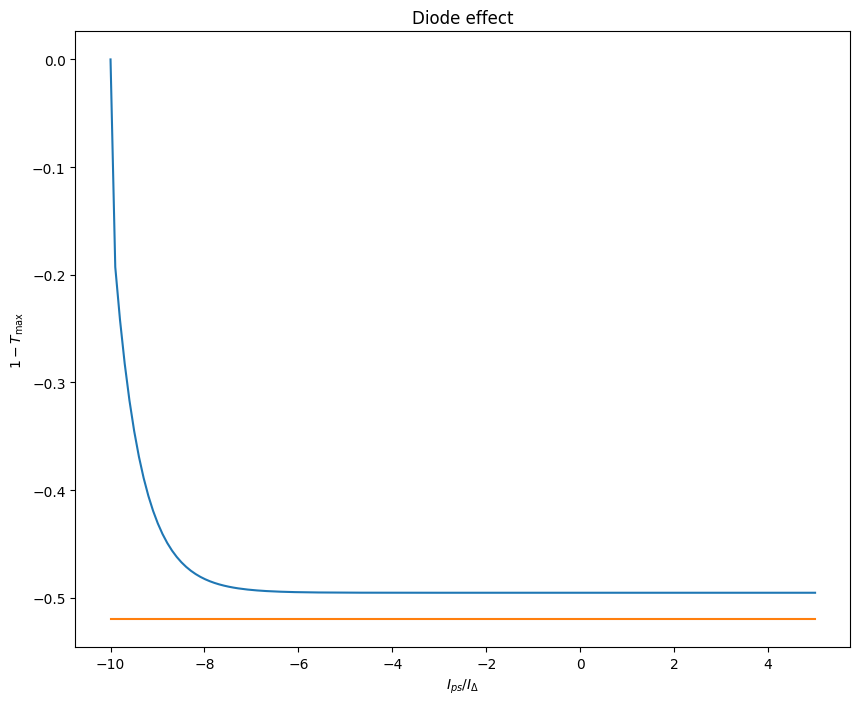

In [5]:
I_c = 37.3
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$1 - T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}/I_{\Delta}$')
axs.set_title(r'Diode effect')

dc_offset = 0.52
index = 1
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
x_data = np.max(np.array(crt_dict['pulse_in']), axis = 1) - dc_offset 
crt_transmitivity = (np.max(crt_dict['current_vs_time'], axis = 1) - dc_offset)/ (x_data )
for i in range(0,1):
    plt.plot(np.array(crt_dict['times'])[i],np.array(crt_dict['current_vs_time'])[i])
    plt.plot(np.array(crt_dict['times'])[i],np.array(crt_dict['pulse_in'])[i])
print(crt_dict['current_vs_time'][0][np.where(crt_dict['times'][0] > -9)[0] ])

## Rectification pulses

In [5]:
import numpy as np
#TODO: Change
title, data_x_unb,data_y_unb = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/Rect_pulse_unbiased.dat')
title, data_x_pos, data_y_pos = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/Rect_pulse_pos_bias.dat')
title, data_x_neg, data_y_neg = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/Rect_pulse_neg_bias.dat')

eta_list = [0.15]
temp_list = [0.45]
phonon_scattering_list = [0.00]
labels = []
dc_biases = [0.49,-0.49,0.0]
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            for dc_bias in dc_biases:
                filename = 'Quasi-static-evolution-T_rect:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + ' DC_bias:' + str(np.round(dc_bias,2)) + '.pkl'
                data_theory_dictionaries += [load_file(filename)]
                labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(150, 2)
(150, 2)
(150, 2)
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(1, 800)


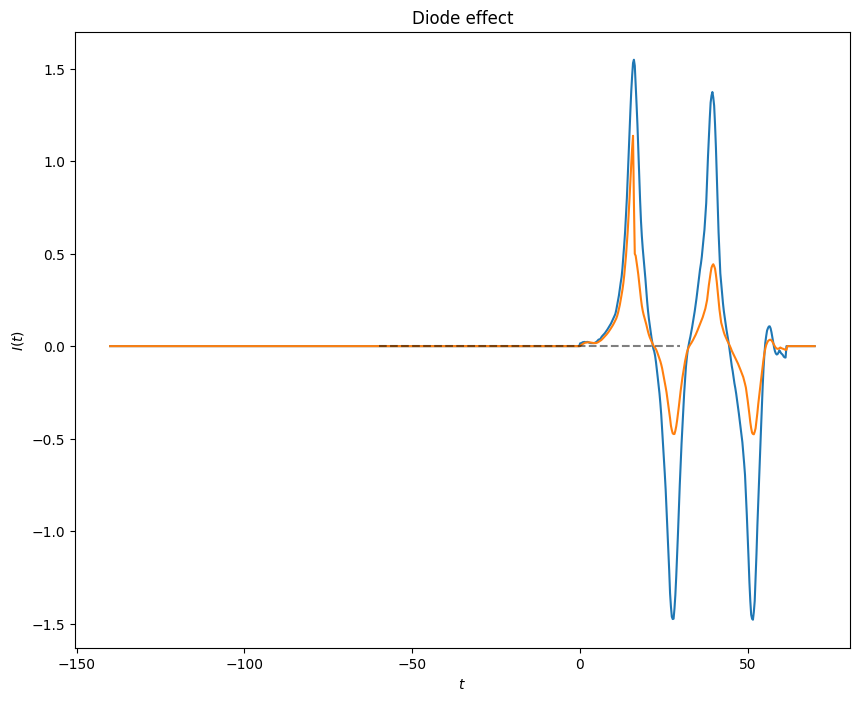

In [6]:
I_c = 37.3 * 8/10 
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$I(t)$')
axs.set_xlabel(r'$t$')
axs.set_title(r'Diode effect')

dc_offset = 0.49
index = 2
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
for i in range(0,1):
    plt.plot(np.array(crt_dict['times'])[i],np.array(crt_dict['pulse_in'])[i])
    plt.plot(np.array(crt_dict['times'])[i],np.array(crt_dict['current_vs_time'])[i])

plt.hlines(0.0,-60,30, 'k', 'dashed',alpha = 0.5)

dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(1, 800)
(133, 2)


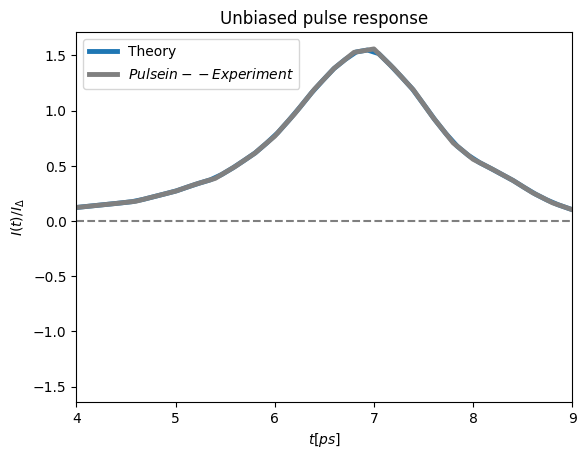

In [7]:
index = 2
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
tc_rescaling = crt_dict['t_scan_T_c_scaling']

for i in range(0,1):
    plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['pulse_in'])[i],linewidth = 3.5, label = 'Theory')
    #plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['current_vs_time'])[i], linewidth = 3.5, label = 'Theory')

#print(tc_rescaling)
plt.hlines(0.0,-60,30, 'k', 'dashed',alpha = 0.5)


title, data_x_in, data_y_in = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/Rect_pulse_in.dat')

plt.plot(data_x_in, data_y_in/(37.3 * 8/10), color = 'grey',label = r'$Pulse in -- Experiment$', linewidth = 3.5)

plt.xlim(4,9)
plt.title('Unbiased pulse response')
plt.ylabel(r'$I(t)/I_\Delta$')
plt.xlabel(r'$t[ps]$')
plt.legend()



### Unbiased pulse

dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(1, 800)
0.83793104
29.532


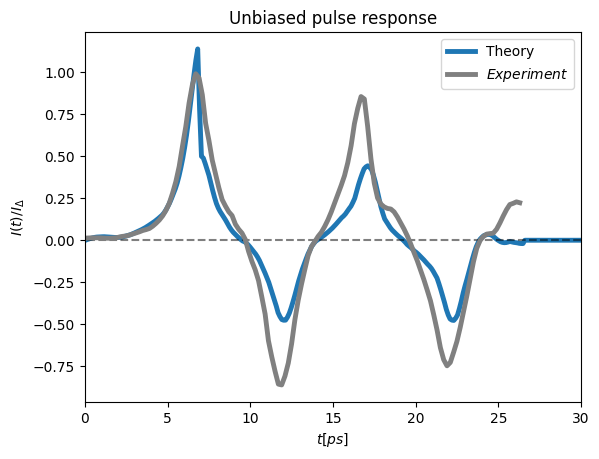

In [8]:
index = 2
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
tc_rescaling = crt_dict['t_scan_T_c_scaling']

for i in range(0,1):
    #plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['pulse_in'])[i])
    plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['current_vs_time'])[i], linewidth = 3.5, label = 'Theory')

print(tc_rescaling)
plt.hlines(0.0,-60,30, 'k', 'dashed',alpha = 0.5)

plt.plot(data_x_unb - 3.5, data_y_unb/(37.3 * 8/10), color = 'grey',label = r'$Experiment$', linewidth = 3.5)
print(np.max(data_y_unb))
plt.xlim(0,30)
plt.title('Unbiased pulse response')
plt.ylabel(r'$I(t)/I_\Delta$')
plt.xlabel(r'$t[ps]$')
plt.legend()



### Positively biased pulse 

dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(1, 800)
0.83793104
29.532


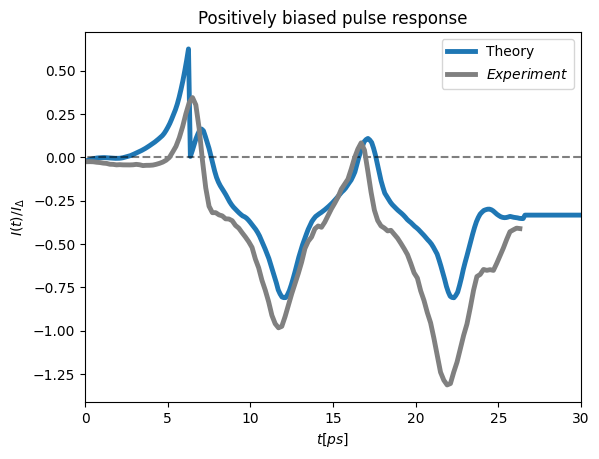

In [9]:
index = 0
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
tc_rescaling = crt_dict['t_scan_T_c_scaling']
dc_bias = 0.49  
for i in range(0,1):
    #plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['pulse_in'])[i])
    plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['current_vs_time'])[i] - dc_bias, linewidth = 3.5, label = 'Theory')

print(tc_rescaling) 
plt.hlines(0.0,-60,30, 'k', 'dashed',alpha = 0.5)

plt.plot(data_x_neg - 3.5, data_y_neg/(37.3 * 8/10), color = 'grey',label = r'$Experiment$', linewidth = 3.5)
print(np.max(data_y_unb))
plt.xlim(0,30)
plt.title('Positively biased pulse response')
plt.ylabel(r'$I(t)/I_\Delta$')
plt.xlabel(r'$t[ps]$')
plt.legend()



### Negatively biased pulse

dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(1, 800)
0.83793104
29.532


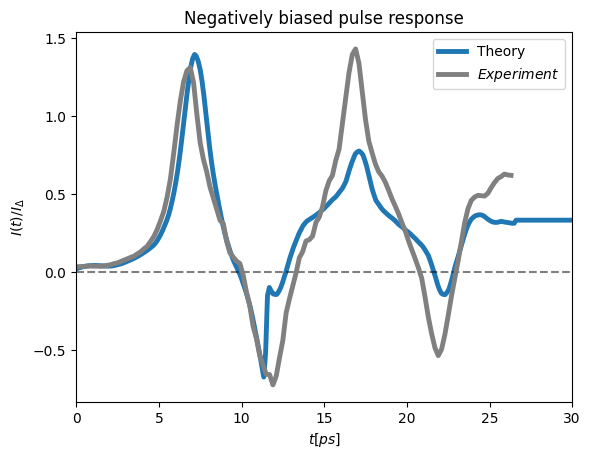

In [10]:
index = 1
crt_dict = data_theory_dictionaries[index ]
print(crt_dict.keys())
print(np.shape(crt_dict['current_vs_time']))
tc_rescaling = crt_dict['t_scan_T_c_scaling']
dc_bias = -0.49
for i in range(0,1):
    #plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['pulse_in'])[i])
    plt.plot(np.array(crt_dict['times'])[i] / (0.02 * 15.5/tc_rescaling * 2 * np.pi),np.array(crt_dict['current_vs_time'])[i] - dc_bias, linewidth = 3.5, label = 'Theory')

print(tc_rescaling)
plt.hlines(0.0,-60,30, 'k', 'dashed',alpha = 0.5)

plt.plot(data_x_pos - 3.5, data_y_pos/(37.3 * 8/10), color = 'grey',label = r'$Experiment$', linewidth = 3.5)
print(np.max(data_y_unb))
plt.xlim(0,30)
plt.title('Negatively biased pulse response')
plt.ylabel(r'$I(t)/I_\Delta$')
plt.xlabel(r'$t[ps]$')
plt.legend()

